# CELL 1 — Environment Setup & Imports

In [52]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image
from pathlib import Path

from IPython.display import display
import ipywidgets as widgets

# Add CellViT repo
sys.path.append("../CellViT-plus-plus")

from cellvit.training.evaluate.inference_cellvit_experiment_pannuke import InferenceCellViT


# CELL 2 — Load input image (256x256 PNG)

Loaded image: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256/images/TCGA-G7-A8LD-01Z-00-DX1_5_512_256.png
Shape: (256, 256, 3)
Dtype: uint8
Min / Max: 12 255


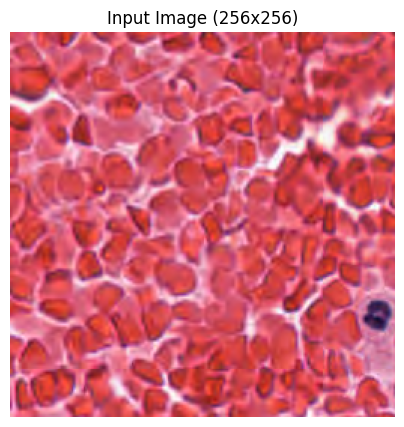

In [53]:
IMAGE_PATH = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/fold0/images/TCGA-55-1594-01Z-00-DX1_001_0_768.png"
IMAGE_PATH = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_3/patches_cellvit_p256/images/TCGA-78-7152-01Z-00-DX1_001_0_0.png"
#image_name = "TCGA-78-7152-01Z-00-DX1_001_0_0"
image_name = "TCGA-G7-A8LD-01Z-00-DX1_5_512_256"
IMAGE_PATH = f"/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256/images/{image_name}.png"

assert os.path.exists(IMAGE_PATH), f"Image not found: {IMAGE_PATH}"

img = Image.open(IMAGE_PATH).convert("RGB")
img_np = np.array(img)

print("Loaded image:", IMAGE_PATH)
print("Shape:", img_np.shape)
print("Dtype:", img_np.dtype)
print("Min / Max:", img_np.min(), img_np.max())

plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.title("Input Image (256x256)")
plt.axis("off")
plt.show()


# Cell 2 — Device & paths

In [54]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

MAGNIFICATION = 40

ROOT_PATH = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/")

# Example model runs (add/remove freely)
#MODEL_RUNS = {
    #"SAM-H Baseline": ROOT_PATH / "ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local/2025-12-05T174106_tcga_finetune_256",
#    "FiLM":     ROOT_PATH / "ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2025-12-05T191217_film256",
#    "Virchow":    ROOT_PATH / "ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_virchow/2025-12-06T223702_tcga_finetune_256_virchow",
#    "Virchow":    ROOT_PATH / "ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_virchow_film/2025-12-06T232801_First film try same with patch size 256",
#}

MODEL_RUNS = {
    # "SAM-H Baseline (Prev)": ROOT_PATH / "ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local/2025-12-05T174106_tcga_finetune_256",
    "FiLM Rosie Weights SamH Baseline": ROOT_PATH / "ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2026-02-11T233928_FilmRosieWeights-samhbaseline",
    "FiLM Rosie Weights z1z4": ROOT_PATH / "ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2026-02-11T233928_FilmRosieWeights-z1z4",
    "FiLM Rosie Weights z3z4": ROOT_PATH / "ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2026-02-11T234426_FilmRosieWeights-z3z4",
    "FiLM Rosie Weights z4": ROOT_PATH / "ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2026-02-11T233928_FilmRosieWeights-z4",
    
    
}
CHECKPOINT_NAME = "model_best.pth"


Using device: cuda


# Cell 3 — Load GT label maps (CellViT format)

In [55]:
GT_MAP_PATH = ROOT_PATH / f"ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256/patch_label_maps/{image_name}.npy"

maps = np.load(GT_MAP_PATH, allow_pickle=True).item()

gt_inst_map = maps["inst_map"].astype(np.int32)
gt_type_map = maps["type_map"].astype(np.int32)

print("GT instance IDs:", np.unique(gt_inst_map)[:10], "...")
print("GT type IDs:", np.unique(gt_type_map))


GT instance IDs: [0 5 7] ...
GT type IDs: [0 4]


# Cell 4 — Align GT labels → model label space

In [56]:
# Ground-truth label semantics
gt_id_to_name = {
    0: "background",
    1: "ambiguous",
    2: "epithelial",
    3: "lymphocyte",
    4: "macrophage",
    5: "neutrophil",
}

# Model label space (from training config)
# Example:
# nuclei_types = {"background":0, "epithelial":1, ..., "other":5}
# (will be loaded from dataset_config later)

def remap_type_map(type_map, gt_id_to_name, gt_to_model_name, model_name_to_id):
    remapped = np.zeros_like(type_map, dtype=np.int32)
    for gt_id, gt_name in gt_id_to_name.items():
        model_name = gt_to_model_name.get(gt_name, "other")
        remapped[type_map == gt_id] = model_name_to_id[model_name]
    return remapped


# Cell 5 — Color-blind–safe LUT & overlay helper

In [57]:
def categorical_colormap(n_classes: int):
    import matplotlib
    cmap = matplotlib.colormaps.get_cmap(
        "Set2" if n_classes <= 8 else "tab20"
    )
    return cmap(np.linspace(0, 1, n_classes + 1))[:, :3]


def build_type_overlay(rgb, type_map, LUT, alpha=0.45):
    rgb = rgb.astype(np.float32) / 255.0
    mask = type_map > 0

    tm = np.clip(type_map, 0, LUT.shape[0] - 1).astype(int)
    color_mask = LUT[tm]
    color_mask[~mask] = 0.0
    color_mask = np.power(color_mask, 0.7)

    overlay = rgb.copy()
    overlay[mask] = (1 - alpha) * overlay[mask] + alpha * color_mask[mask]
    return overlay


# Cell 6 — Load inference pipeline (one model)

In [58]:
# Helper for 
def sanitize_backbone_for_sam(backbone: str) -> str:
    """
    Converts things like 'sam-h-rosie-film' -> 'sam-h'
    Leaves 'sam-h' unchanged.
    """
    if backbone is None:
        return "sam-h"
    s = str(backbone).strip().lower().replace("_", "-")
    if s.startswith("sam-"):
        parts = s.split("-")
        if len(parts) >= 2:
            return "-".join(parts[:2])  # sam-h / sam-l / sam-b
    return s



In [59]:
from pathlib import Path
import torch

def load_cellvit_inference(run_dir):
    inference = InferenceCellViT(
        run_dir=run_dir,
        gpu=0,
        checkpoint_name=CHECKPOINT_NAME,
        magnification=MAGNIFICATION,
    )

    # notebook-only hotfix: make backbone parseable by SAM builder
    bb_raw = inference.run_conf.get("model", {}).get("backbone", "sam-h")
    inference.run_conf["model"]["backbone"] = sanitize_backbone_for_sam(bb_raw)
    print("Backbone (raw -> sanitized):", bb_raw, "->", inference.run_conf["model"]["backbone"])
    # until here

    model, val_loader, dataset_config = inference.setup_patch_inference()
    model = model.to(device).eval()
    return model, val_loader, dataset_config, inference


In [60]:
from cellvit.training.trainer.trainer_cellvit import CellViTTrainer

def build_postprocess_trainer(model, inference, dataset_config, run_dir):
    """
    Create a lightweight CellViTTrainer ONLY for unpack_predictions.
    No training, no logging, no side effects.
    """
    dummy_opt = torch.optim.SGD(model.parameters(), lr=0.1)
    dummy_sched = torch.optim.lr_scheduler.StepLR(
        dummy_opt, step_size=1000, gamma=1.0
    )

    trainer = CellViTTrainer(
        model=model,
        loss_fn_dict={},              # not used
        optimizer=dummy_opt,
        scheduler=dummy_sched,
        device=device,
        logger=inference.logger,
        logdir=run_dir,
        num_classes=len(dataset_config["nuclei_types"]),
        dataset_config=dataset_config,
        experiment_config={},
        early_stopping=None,
        log_images=False,
        magnification=MAGNIFICATION,
        mixed_precision=False,
    )
    return trainer


# Cell 7 — Run inference on one patch

In [61]:
def run_cellvit_on_patch(img_np, model, val_loader, trainer):
    """
    Run CellViT on a single patch and postprocess outputs.
    """
    ds  = val_loader.dataset
    tfm = getattr(ds, "transforms", None) or getattr(ds, "transform", None)
    if tfm is None:
        raise RuntimeError("Dataset has no transforms")

    try:
        img_t = tfm(image=img_np)["image"]
    except TypeError:
        img_t = tfm(Image.fromarray(img_np))

    if isinstance(img_t, np.ndarray):
        img_t = torch.from_numpy(img_t)
    if img_t.ndim == 3 and img_t.shape[-1] == 3:
        img_t = img_t.permute(2,0,1)

    img_t = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(img_t)

    processed = trainer.unpack_predictions(out)

    return {
        "binary_map": processed.nuclei_binary_map[0,1].cpu().numpy(),
        "inst_map":   processed.instance_map[0].cpu().numpy().astype(int),
        "type_map":   torch.argmax(processed.nuclei_type_map, dim=1)[0].cpu().numpy(),
    }


# Cell 8 — Run inference for all models

In [62]:
pred_maps = {}
dataset_config = None

for name, run_dir in MODEL_RUNS.items():
    model, val_loader, dataset_config, inference = load_cellvit_inference(run_dir)

    trainer = build_postprocess_trainer(
        model=model,
        inference=inference,
        dataset_config=dataset_config,
        run_dir=run_dir,
    )

    result = run_cellvit_on_patch(
        img_np=img_np,
        model=model,
        val_loader=val_loader,
        trainer=trainer,
    )

    pred_maps[name] = result["type_map"]

print("Models inferred:", list(pred_maps.keys()))



Loaded run: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2026-02-11T233928_FilmRosieWeights-samhbaseline
Loaded run: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2026-02-11T233928_FilmRosieWeights-samhbaseline
Loaded run: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2026-02-11T233928_FilmRosieWeights-samhbaseline
Loaded run: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2026-02-11T233928_FilmRosieWeights-samhbaseline


✅ Loaded ROSIE weights from: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/rosie/best_model_single.pth
   missing keys: 0 | unexpected keys: 0
Loading best model from /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2026-02-11T233928_FilmRosieWeights-samhbaseline/checkpoints/model_best.pth
Loading best model from /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2026-02-11T233928_FilmRosieWeights-samhbaseline/checkpoints/model_best.pth
Loading best model from /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk

# Cell 9 — Remap GT using dataset config

In [63]:
nuclei_types = dataset_config["nuclei_types"]
id_to_name = {v: k for k, v in nuclei_types.items()}
max_cls_id = max(id_to_name.keys())
LUT = categorical_colormap(max_cls_id)

gt_to_model_name = {
    "background": "background",
    "epithelial": "epithelial",
    "lymphocyte": "lymphocyte",
    "neutrophil": "neutrophil",
    "macrophage": "macrophage",
    "ambiguous": "other",
}

gt_type_map_remapped = remap_type_map(
    gt_type_map,
    gt_id_to_name,
    gt_to_model_name,
    nuclei_types
)


# Cell 10 — GT vs multiple model visualization

In [64]:
# =========================================================
# FINAL COMPARISON FIGURE
# Rows = Representation (Type / Overlay)
# Cols = GT + Models
# =========================================================

def visualize_type_overlay_matrix(
    gt_type_map,
    pred_maps,   # dict: {"model name": type_map}
    rgb,
    title="GT vs Models"
):
    """
    Comparison matrix:
      Columns: GT + models
      Rows:    Type Map / Overlay
    """
    model_names = list(pred_maps.keys())
    col_names = ["GT"] + model_names
    n_cols = len(col_names)
    n_rows = 2  # Type map, Overlay

    # Build overlays
    overlay_gt = build_type_overlay(rgb, gt_type_map, LUT)
    overlay_preds = {
        name: build_type_overlay(rgb, pred_maps[name], LUT)
        for name in model_names
    }

    # --- Create figure ---
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.2 * n_cols, 4.2 * n_rows),
        constrained_layout=True
    )

    # Ensure axes is 2D even if n_cols == 1
    if n_cols == 1:
        axes = axes.reshape(n_rows, 1)

    # -----------------------------
    # Fill the grid
    # -----------------------------
    for col, name in enumerate(col_names):
        # ---- Row 0: Type maps ----
        ax = axes[0, col]
        if name == "GT":
            ax.imshow(gt_type_map, cmap="Set2", vmin=0, vmax=max_cls_id)
        else:
            ax.imshow(pred_maps[name], cmap="Set2", vmin=0, vmax=max_cls_id)
        ax.axis("off")

        # ---- Row 1: Overlays ----
        ax = axes[1, col]
        if name == "GT":
            ax.imshow(overlay_gt)
        else:
            ax.imshow(overlay_preds[name])
        ax.axis("off")

    # -----------------------------
    # Column titles
    # -----------------------------
    for col, name in enumerate(col_names):
        axes[0, col].set_title(name, fontsize=13, pad=8)

    # -----------------------------
    # Row labels (left side)
    # -----------------------------
    axes[0, 0].set_ylabel("Type Map", fontsize=13, rotation=90, labelpad=12)
    axes[1, 0].set_ylabel("Overlay", fontsize=13, rotation=90, labelpad=12)

    # -----------------------------
    # Figure title
    # -----------------------------
    fig.suptitle(title, fontsize=16, y=1.02)

    plt.show()

    # -----------------------------
    # Shared legend
    # -----------------------------
    present = set(np.unique(gt_type_map))
    for pm in pred_maps.values():
        present |= set(np.unique(pm))
    present = sorted(i for i in present if i > 0)

    legend_patches = [
        Patch(color=LUT[i], label=f"{i}: {id_to_name[i]}")
        for i in present
    ]

    plt.figure(figsize=(6, 0.6 + 0.3 * len(present)))
    plt.legend(
        handles=legend_patches,
        title="Cell Types",
        frameon=False,
        loc="center left"
    )
    plt.axis("off")
    plt.show()

# Cell 11 — Run final comparison

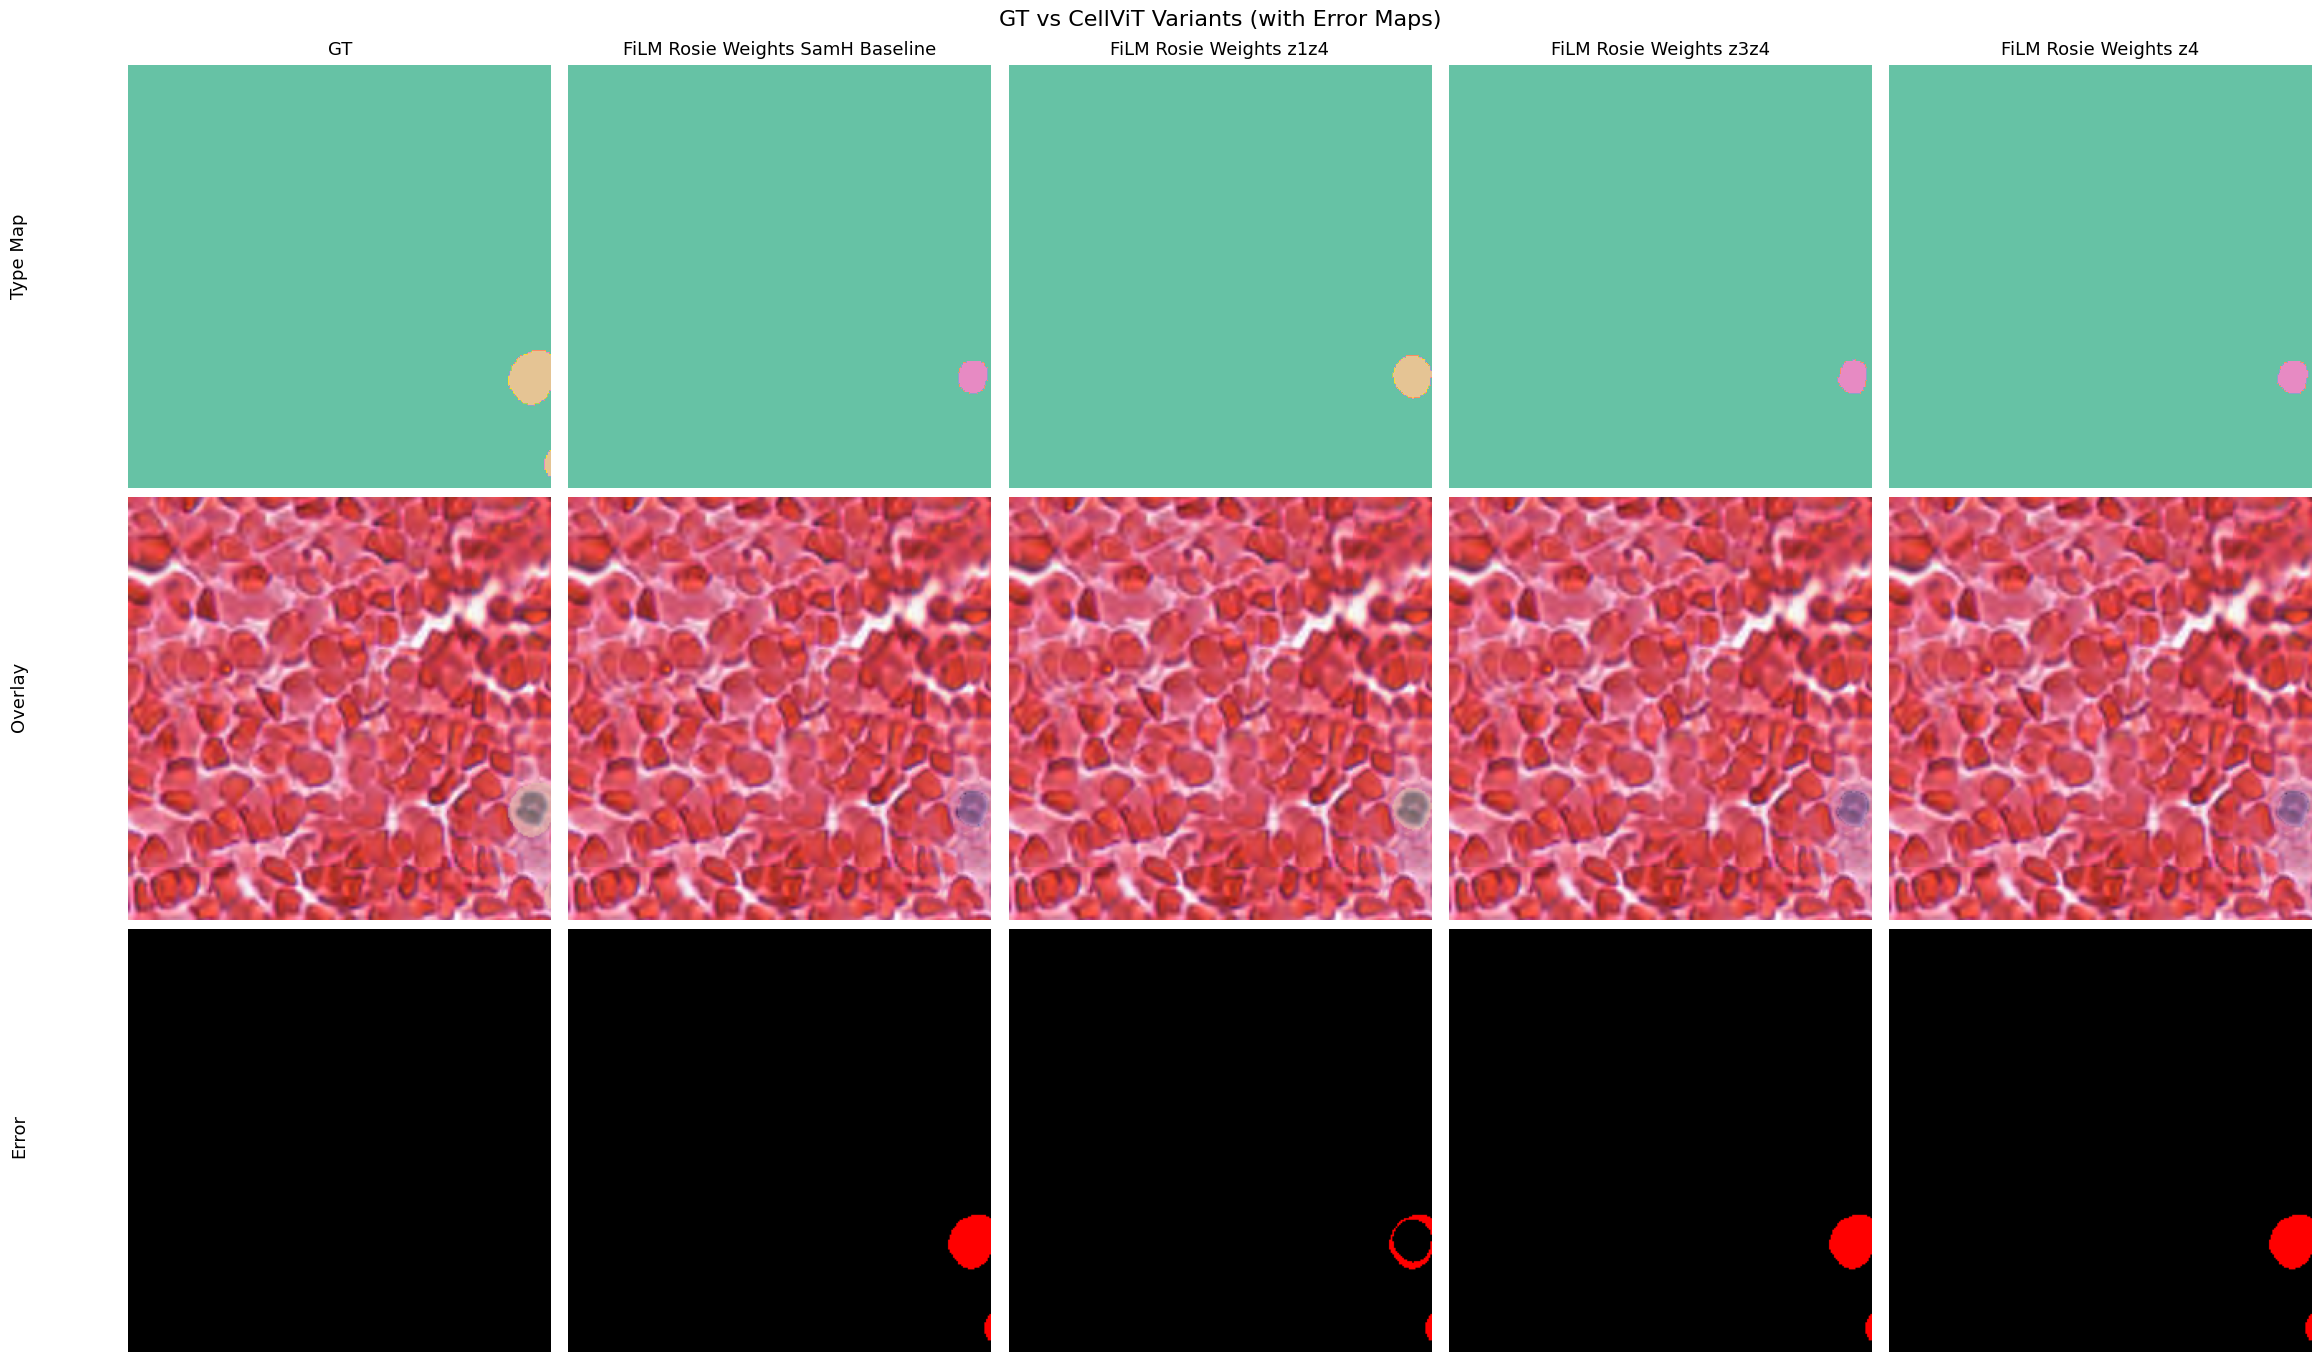

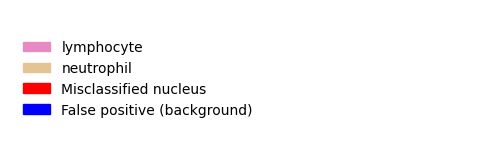

In [65]:
# =========================================================
# FINAL COMPARISON FIGURE + ERROR MAP COLUMN
# Rows = Type / Overlay
# Cols = GT + Models (+ Error)
# =========================================================

def visualize_type_overlay_error_matrix(
    gt_type_map,
    pred_maps,   # dict: {"model name": type_map}
    rgb,
    title="GT vs Models (Type / Overlay / Error)"
):
    """
    Comparison matrix:
      Columns: GT | Model A | Model B | ...
      Rows:    Type Map | Overlay | Error Map
    """
    model_names = list(pred_maps.keys())
    col_names = ["GT"] + model_names
    n_cols = len(col_names)
    n_rows = 3  # Type, Overlay, Error

    # Build overlays
    overlay_gt = build_type_overlay(rgb, gt_type_map, LUT)
    overlay_preds = {
        name: build_type_overlay(rgb, pred_maps[name], LUT)
        for name in model_names
    }

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.4 * n_cols, 4.4 * n_rows),
        constrained_layout=True
    )

    # -----------------------------
    # Fill grid
    # -----------------------------
    for col, name in enumerate(col_names):

        # ---------- Row 0: Type map ----------
        ax = axes[0, col]
        if name == "GT":
            ax.imshow(gt_type_map, cmap="Set2", vmin=0, vmax=max_cls_id)
        else:
            ax.imshow(pred_maps[name], cmap="Set2", vmin=0, vmax=max_cls_id)
        ax.axis("off")

        # ---------- Row 1: Overlay ----------
        ax = axes[1, col]
        if name == "GT":
            ax.imshow(overlay_gt)
        else:
            ax.imshow(overlay_preds[name])
        ax.axis("off")

        # ---------- Row 2: Error map ----------
        ax = axes[2, col]

        if name == "GT":
            ax.imshow(np.zeros_like(gt_type_map), cmap="gray")
        else:
            pred_map = pred_maps[name]

            misclass = (gt_type_map > 0) & (pred_map != gt_type_map)
            false_pos = (gt_type_map == 0) & (pred_map > 0)

            error_map = np.zeros((*gt_type_map.shape, 3), dtype=np.float32)
            error_map[misclass] = [1.0, 0.0, 0.0]   # red
            error_map[false_pos] = [0.0, 0.0, 1.0]  # blue

            ax.imshow(error_map)

        ax.axis("off")


    # -----------------------------
    # Column titles
    # -----------------------------
    for col, name in enumerate(col_names):
        axes[0, col].set_title(name, fontsize=13, pad=8)

    # -----------------------------
    # Row labels
    # -----------------------------
    axes[0, 0].set_ylabel("Type Map", fontsize=13, labelpad=12)
    axes[1, 0].set_ylabel("Overlay", fontsize=13, labelpad=12)
    axes[2, 0].set_ylabel("Error", fontsize=13, labelpad=12)

    # -----------------------------
    # Figure title
    # -----------------------------
    fig.suptitle(title, fontsize=16, y=1.02)
    # -----------------------------
    # Proper row titles (figure-level)
    # -----------------------------
    row_labels = ["Type Map", "Overlay", "Error"]

    for row, label in enumerate(row_labels):
        # y-position: middle of each row (top to bottom)
        y = 1 - (row + 0.5) / len(row_labels)
        fig.text(
            -0.05, y,
            label,
            va="center",
            ha="left",
            fontsize=13,
            rotation=90,
        )

    plt.show()

    # -----------------------------
    # Shared legend (cell types)
    # -----------------------------
    present = set(np.unique(gt_type_map))
    for pm in pred_maps.values():
        present |= set(np.unique(pm))
    present = sorted(i for i in present if i > 0)

    legend_patches = [
        Patch(color=LUT[i], label=id_to_name[i])
        for i in present
    ]

    # Error legend
    legend_patches.append(Patch(color="red", label="Misclassified nucleus"))
    legend_patches.append(Patch(color="blue", label="False positive (background)"))

    plt.figure(figsize=(6, 0.6 + 0.3 * len(legend_patches)))
    plt.legend(
        handles=legend_patches,
        frameon=False,
        loc="center left"
    )
    plt.axis("off")
    plt.show()
remap = False
if remap:
    visualize_type_overlay_error_matrix(
        gt_type_map=gt_type_map_remapped,
        pred_maps=pred_maps,
        rgb=img_np,
        title="GT vs CellViT Variants (with Error Maps)"
    )
else:
    visualize_type_overlay_error_matrix(
        gt_type_map=gt_type_map,
        pred_maps=pred_maps,
        rgb=img_np,
        title="GT vs CellViT Variants (with Error Maps)"
    )
